# 01 — Verificación del modelo Saint-Venant 1D

Verifica que el solver en `src/model.py` produce resultados físicamente razonables antes de calibrar.
La única celda que el usuario debe modificar es la de **Configuración**.

## Modelo

$$\frac{\partial A}{\partial t} + \frac{\partial Q}{\partial x} = 0 \qquad\qquad \frac{\partial Q}{\partial t} + \!\frac{\partial}{\partial x}\frac{Q^2}{A} + \frac{\partial}{\partial x}\frac{hgA}{2}\ - gA(S_0 - S_f) = 0$$

Canal rectangular: $\;A = B_w h,\quad R = A\,/\,(B_w+2h),\quad S_f = n^2 Q|Q|\,/\,(A^2 R^{4/3})$

## Esquema numérico — MacCormack

**Predictor** : $\quad\hat{U}_i = U_i - \dfrac{\Delta t}{\Delta x}(F_{i+1}-F_i) + \Delta t\,S_i$

**Corrector** : $\quad U_i^{n+1} = \tfrac{1}{2}\!\left[U_i + \hat{U}_i - \dfrac{\Delta t}{\Delta x}(\hat{F}_i - \hat{F}_{i-1}) + \Delta t\,\hat{S}_i\right]$

**CFL**: $\;\Delta t \leq 0.9\,\Delta x\;/\max_i(|u_i|+\sqrt{gh_i})$

**CI**: $h(x,0)=h_n(Q_0),\;Q(x,0)=Q_0$ $\quad$ **CB**: $Q(0,t)=Q_\text{in}(t)$ aguas arriba; gradiente nulo en $x=L$

In [3]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.model as _model_module
importlib.reload(_model_module)
from src.model import saint_venant_1d, run_batch, normal_depth

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

TRUE_PARAMS = [0.035, 0.001, 50.0]   # [n, S0, B_w], parametros definidos por parte del usuario o grupo de proyecto

df_params = pd.DataFrame({
    "Parámetro":        ["Manning (n)", "Pendiente de fondo (S₀)", "Ancho del canal (B_w)"],
    "Símbolo":          ["n",           "S₀",                      "B_w"],
    "Valor verdadero":  [0.035,         0.001,                     50.0],
    "Rango calibración":["0.010–0.060", "0.0001–0.005",            "20–80"],
    "Unidades":         ["—",           "—",                       "m"],
})
df_dominio = pd.DataFrame({
    "Variable": ["Longitud (L)", "Celdas (nx)", "Δx", "Estabilidad CFL"],
    "Valor":    ["5 000 m",      "100",          "50 m", "0.9 · Δx / (|u| + √(gh))"],
})
print("=== Parámetros calibrables ===")
display(df_params)
print("\n=== Dominio numérico ===")
display(df_dominio)

=== Parámetros calibrables ===


,Parámetro,Símbolo,Valor verdadero,Rango calibración,Unidades
0,Manning (n),n,0.035,0.010–0.060,—
1,Pendiente de fondo (S₀),S₀,0.001,0.0001–0.005,—
2,Ancho del canal (B_w),B_w,50.000,20–80,m



=== Dominio numérico ===


,Variable,Valor
0,Longitud (L),5 000 m
1,Celdas (nx),100
2,Δx,50 m
3,Estabilidad CFL,0.9 · Δx / (|u| + √(gh))


## Configuración
Única celda que se modifica para cambiar el dataset.

In [11]:
CSV_PATH = ROOT / "data" / "synthetic" / "series_corta_balance.csv"

resultado = run_batch(str(CSV_PATH), TRUE_PARAMS)
print(f"Filas totales : {len(resultado):,}")
print(f"Filas warmup  : {resultado['is_warmup'].sum()}")
print((resultado.keys()))
display(resultado.head())

Filas totales : 500
Filas warmup  : 4
Index(['datetime', 'Q_upstream_m3s', 'q_lat_m3s', 'Q_downstream_m3s',
       'h_outlet_m', 'Q_sim_m3s', 't_seconds', 'is_warmup', 'residual_m3s'],
      dtype='object')


,datetime,Q_upstream_m3s,q_lat_m3s,Q_downstream_m3s,h_outlet_m,Q_sim_m3s,t_seconds,is_warmup,residual_m3s
0,2022-01-01 00:00:00,25.984,2.894,28.878,1.0249,25.984000,0.0,True,2.894000
1,2022-01-01 00:15:00,8.595,1.398,9.993,0.9131,25.985654,900.0,True,-15.992654
2,2022-01-01 00:30:00,24.450,2.894,27.344,1.0330,25.990075,1800.0,True,1.353925
3,2022-01-01 00:45:00,57.792,2.024,59.816,1.0777,25.995791,2700.0,True,33.820209
4,2022-01-01 01:00:00,79.083,2.439,81.522,1.2733,26.001440,3600.0,False,55.520560


## Métricas rápidas
Calculadas fuera del período de calentamiento.

In [5]:
eval_df = resultado[~resultado["is_warmup"]]
obs  = eval_df["Q_downstream_m3s"].to_numpy()
sim  = eval_df["Q_sim_m3s"].to_numpy()

mae   = np.mean(np.abs(obs - sim))
rmse  = np.sqrt(np.mean((obs - sim) ** 2))
bias  = np.mean(sim - obs)
r     = np.corrcoef(obs, sim)[0, 1]
denom = np.sum((obs - np.mean(obs)) ** 2)
nse   = float(1.0 - np.sum((obs - sim) ** 2) / denom) if denom > 0 else np.nan

pd.Series({
    "NSE":          nse,
    "MAE [m³/s]":   mae,
    "RMSE [m³/s]":  rmse,
    "Bias [m³/s]":  bias,
    "r":            r,
}).to_frame("valor").round(4)

,valor
NSE,-0.8344
MAE [m³/s],70.1576
RMSE [m³/s],95.0891
Bias [m³/s],-63.5841
r,0.0851


## Test A — Entrada upstream variable
El solver usa el hidrograma sintético completo como condición de frontera aguas arriba, sin imponer un caudal constante.

In [ ]:
n, S0, B_w = TRUE_PARAMS
q_test = resultado["Q_upstream_m3s"].to_numpy(dtype=float)
t_test = resultado["t_seconds"].to_numpy(dtype=float)
h_teo = np.array([normal_depth(q, B_w, n, S0) for q in q_test])

Q_sim_variable = saint_venant_1d(
    TRUE_PARAMS,
    q_test,
    t_test,
    warmup_seconds=3600.0,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_test / 60, q_test, color="0.35", lw=1.2, label="Q upstream datos")
ax.plot(t_test / 60, Q_sim_variable, color="steelblue", lw=1.4, label="Q_sim salida")
ax.set_xlabel("Tiempo [min]")
ax.set_ylabel("Q [m³/s]")
ax.set_title("Test A — Respuesta del solver al hidrograma upstream sintético")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01a_variable_upstream.png", dpi=200)
plt.show()

print(f"Tirante normal Manning, rango : {h_teo.min():.4f}–{h_teo.max():.4f} m")
print(f"Q upstream, rango             : {q_test.min():.3f}–{q_test.max():.3f} m³/s")
print(f"Q_sim salida, rango           : {Q_sim_variable.min():.3f}–{Q_sim_variable.max():.3f} m³/s")

## Test B — Conservación de masa
Volumen acumulado de entrada vs. salida a lo largo de toda la serie.

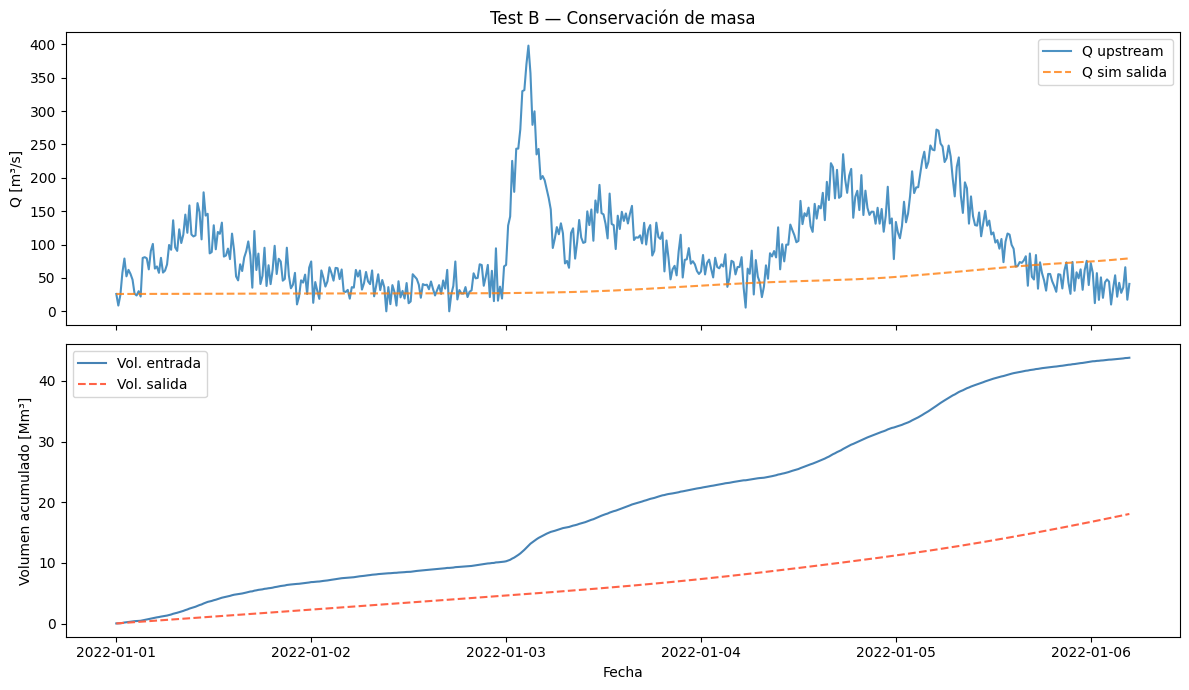

Vol. entrada : 43.83 Mm³
Vol. salida  : 18.07 Mm³
Error rel.   : 58.76 %


In [7]:
t_arr  = resultado["t_seconds"].to_numpy()
dt_arr = np.diff(t_arr, prepend=t_arr[0])
dt_arr[0] = dt_arr[1]   # primer intervalo igual al segundo

V_in  = np.cumsum(resultado["Q_upstream_m3s"].to_numpy() * dt_arr)
V_out = np.cumsum(resultado["Q_sim_m3s"].to_numpy()       * dt_arr)
err_rel = (V_in[-1] - V_out[-1]) / V_in[-1] * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(resultado["datetime"], resultado["Q_upstream_m3s"],
             label="Q upstream", alpha=0.8)
axes[0].plot(resultado["datetime"], resultado["Q_sim_m3s"],
             label="Q sim salida", alpha=0.8, ls="--")
axes[0].set_ylabel("Q [m³/s]")
axes[0].legend()
axes[0].set_title("Test B — Conservación de masa")

axes[1].plot(resultado["datetime"], V_in  / 1e6, label="Vol. entrada", color="steelblue")
axes[1].plot(resultado["datetime"], V_out / 1e6, label="Vol. salida",  color="tomato", ls="--")
axes[1].set_ylabel("Volumen acumulado [Mm³]")
axes[1].set_xlabel("Fecha")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01b_mass_conservation.png", dpi=200)
plt.show()

print(f"Vol. entrada : {V_in[-1]/1e6:.2f} Mm³")
print(f"Vol. salida  : {V_out[-1]/1e6:.2f} Mm³")
print(f"Error rel.   : {err_rel:.2f} %")

## Demo — Paralelización con joblib
Muestra cómo lanzar múltiples simulaciones en paralelo; patrón que usarán Sobol y GLUE.

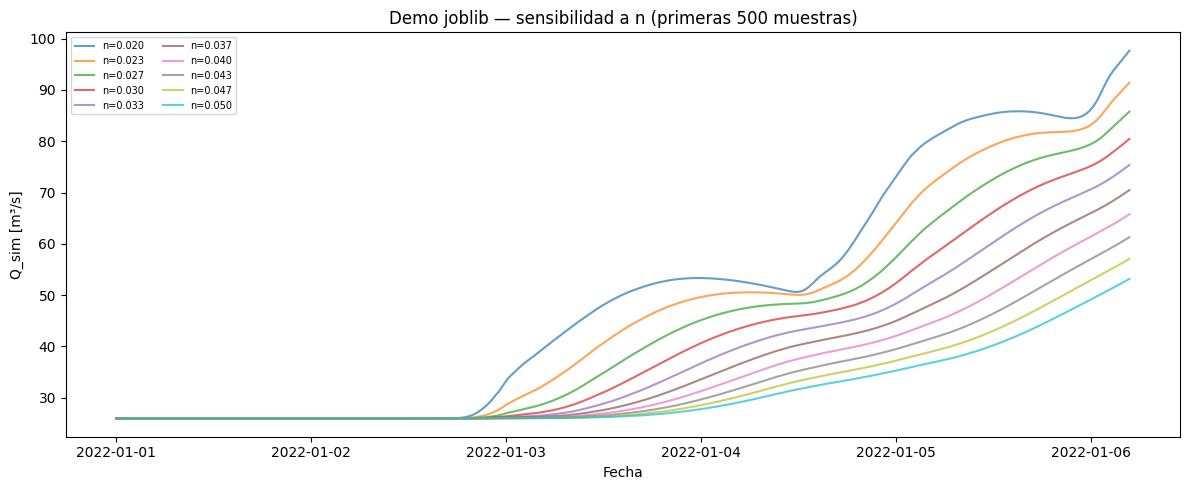

10 simulaciones en paralelo completadas.


In [8]:
n, S0, B_w = TRUE_PARAMS
q_up  = resultado["Q_upstream_m3s"].to_numpy()
t_sec = resultado["t_seconds"].to_numpy()
n_vals = np.linspace(0.020, 0.050, 10)

def _run_one(n_val):
    return saint_venant_1d([n_val, S0, B_w], q_up, t_sec)

Q_parallel = Parallel(n_jobs=-1)(delayed(_run_one)(nv) for nv in n_vals)

WIN = 500
fig, ax = plt.subplots(figsize=(12, 5))
for nv, Q_s in zip(n_vals, Q_parallel):
    ax.plot(resultado["datetime"].iloc[:WIN], Q_s[:WIN], alpha=0.7, label=f"n={nv:.3f}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Q_sim [m³/s]")
ax.set_title("Demo joblib — sensibilidad a n (primeras 500 muestras)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01c_joblib_demo.png", dpi=200)
plt.show()

print(f"{len(n_vals)} simulaciones en paralelo completadas.")